# Laboratorio 3: Regresión Logística Binaria con Gradient Descent

**Maestría en Machine Learning — Aula: Gradient Descent**

---

## Objetivo

Este laboratorio aplica las técnicas de Gradient Descent estudiadas en los Laboratorios 1 y 2
a un modelo de **clasificación supervisada**: la **Regresión Logística Binaria**.

Se abordan:

1. La **función de costo** (Binary Cross-Entropy / Log-Loss).
2. El **gradiente** de la función de costo con respecto a los pesos.
3. La implementación de una **clase Python** con API compatible con scikit-learn (`fit` / `predict`).


---
## Configuración Inicial

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

plt.rcParams.update({
    'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'lines.linewidth': 2
})
np.random.seed(42)
print('Entorno configurado.')

Entorno configurado.


---
## Paso 1: Generación de Datos Sintéticos para Clasificación Binaria

Generamos un dataset de clasificación binaria con dos features. Las dos clases
son linealmente separables (con algo de ruido), lo que permite que la regresión logística
funcione bien.

In [2]:
# --- Generar datos sintéticos de clasificación binaria ---
n_samples = 400

# Clase 0
n0 = n_samples // 2
# gaussiana centrada en (2, 2)
X0 = np.random.randn(n0, 2) + np.array([2, 2])

# Clase 1
n1 = n_samples - n0
#gaussiana centrada en (-2, -2)
X1 = np.random.randn(n1, 2) + np.array([-2, -2])

X_raw = np.vstack([X0, X1])
y = np.hstack([np.zeros(n0), np.ones(n1)])

# Mezclar los datos
indices = np.random.permutation(n_samples)
X_raw = X_raw[indices]
y = y[indices]

print(f'X_raw shape: {X_raw.shape}')
print(f'y shape: {y.shape}')
print(f'Distribución de clases: Clase 0 = {np.sum(y == 0):.0f}, Clase 1 = {np.sum(y == 1):.0f}')

X_raw shape: (400, 2)
y shape: (400,)
Distribución de clases: Clase 0 = 200, Clase 1 = 200


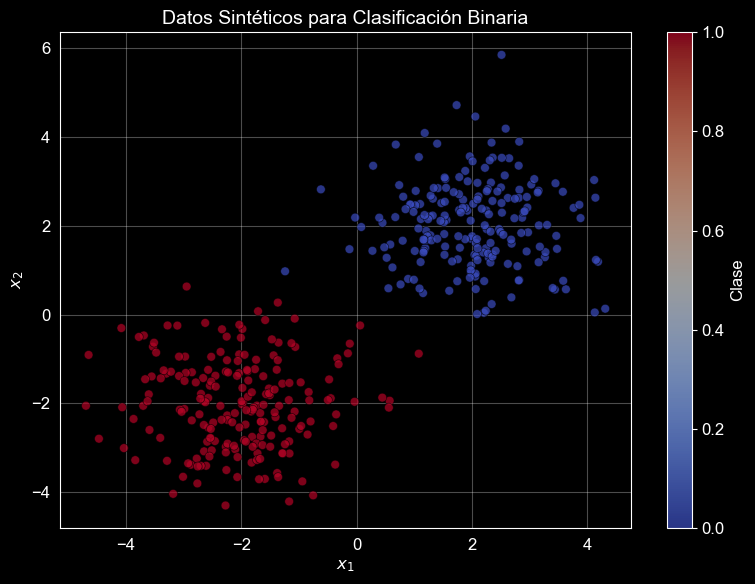

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_raw[:, 0], X_raw[:, 1], c=y, cmap='coolwarm',
                     alpha=0.7, edgecolors='black', linewidths=0.5, s=40)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Datos Sintéticos para Clasificación Binaria')
plt.colorbar(scatter, label='Clase')
plt.tight_layout(); plt.show()

---
## Paso 2: Preparación — Augmentar la  Matrix con un Bias Term (columna de 1s)

Al igual que en la regresión lineal, aumentamos la Design Matrix con una columna de unos
para incorporar el bias term:

$$\mathbf{X}_{\text{aug}} = \begin{bmatrix} 1 & x_{11} & x_{12} \\
1 & x_{21} & x_{22} \\ \vdots & \vdots & \vdots \\
1 & x_{n1} & x_{n2} \end{bmatrix} \in \mathbb{R}^{n \times 3}$$

**NumPy:** `np.c_[np.ones((n, 1)), X]` añade una columna de unos al inicio.

In [4]:
# --- Augmentar la Design Matrix ---
X = np.c_[np.ones((n_samples, 1)), X_raw]
print(f'X (augmented) shape: {X.shape}')
print(f'Primeras 5 filas de X:\n{X[:5]}')

X (augmented) shape: (400, 3)
Primeras 5 filas de X:
[[ 1.         -1.66150359 -2.41528791]
 [ 1.         -2.45006547 -1.37715007]
 [ 1.         -2.52272302 -0.95099077]
 [ 1.         -1.97168162 -1.97024386]
 [ 1.         -2.98960482 -2.12578692]]


---
## Paso 3: Modelo de Regresión Logística

### Función Sigmoide

La regresión logística utiliza la **función sigmoide** para mapear la combinación lineal
$z = \mathbf{X}\mathbf{w}$ al rango $[0, 1]$, interpretándola como una probabilidad:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### Predicción

$$\hat{y}_i = \sigma(\mathbf{x}_i^\top \mathbf{w}) = \frac{1}{1 + e^{-\mathbf{x}_i^\top \mathbf{w}}}$$

### Función de Costo — Binary Cross-Entropy (Log-Loss)

$$J(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

### Vector Gradiente

Derivando la función de costo respecto a $\mathbf{w}$, se obtiene una expresión notablemente
similar a la de regresión lineal:

$$\nabla_{\mathbf{w}} J = \frac{1}{n} \mathbf{X}^\top (\hat{\mathbf{y}} - \mathbf{y})$$

donde $\hat{\mathbf{y}} = \sigma(\mathbf{X}\mathbf{w})$ es el vector de probabilidades predichas.


> **Nota numérica:** Para evitar `log(0)`, se usa `np.clip(y_pred, epsilon, 1 - epsilon)` con un epsilon pequeño.

### Tarea 1: Implementar `sigmoid`, `calcular_log_loss` y `calcular_gradiente`

Utiliza las fórmulas anteriores para completar las siguientes funciones usando operaciones
vectorizadas de NumPy.

In [5]:
def sigmoid(z):
    """
    Función sigmoide: sigma(z) = 1 / (1 + exp(-z))
    """
    return 1 / (1 + np.exp(-z))

def calcular_log_loss(X, y, w):
    """
    Binary Cross-Entropy (Log-Loss):
    J(w) = -(1/n) * sum[ y*log(y_hat) + (1-y)*log(1-y_hat) ]
    """
    n = len(y)
    epsilon = 1e-7 #Para evitar log(0)
    y_hat = sigmoid(X @ w)
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def calcular_gradiente(X, y, w):
    """
    Gradiente de la Log-Loss:
    nabla J = (1/n) * X^T * (sigma(X*w) - y)
    """
    n = len(y)
    y_hat = sigmoid(X @ w)
    return (1 / n) * X.T @ (y_hat - y)

---
## Paso 4: División Train / Test y Entrenamiento con Gradient Descent

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \alpha\,\nabla_{\mathbf{w}} J(\mathbf{w}^{(t)})$$

In [6]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

Train: 320 muestras
Test:  80 muestras


### Tarea 2: Implementar el bucle de Gradient Descent

En cada epoch:
1. Calcular el loss con `calcular_log_loss`
2. Calcular el gradiente con `calcular_gradiente`
3. Actualizar los pesos: `w = w - lr * grad`
4. Guardar el loss en `loss_history`

In [8]:
lr = 0.1 # TODO Elegir una tasa de aprendizaje adecuada
n_epochs = 300 # TODO Elegir un número de épocas adecuado
w = np.zeros(X_train.shape[1])
loss_history = []

# TODO: Implementar el bucle de Gradient Descent
for epoch in range(n_epochs):
    loss = calcular_log_loss(X_train, y_train, w) #Calculamos el loss
    grad = calcular_gradiente(X_train, y_train, w) #Calculmos el gradiente
    w = w - lr * grad #Actualizamos ls pesos
    loss_history.append(loss) # Guardamos el loss

loss_value = f"{loss_history[-1]:.6f}" if loss_history else "N/A"
print(f'Pesos finales: {w}')
print(f'Loss final: {loss_value}')

Pesos finales: [ 0.06312841 -1.37823833 -1.59339551]
Loss final: 0.018838


### Learning Curve

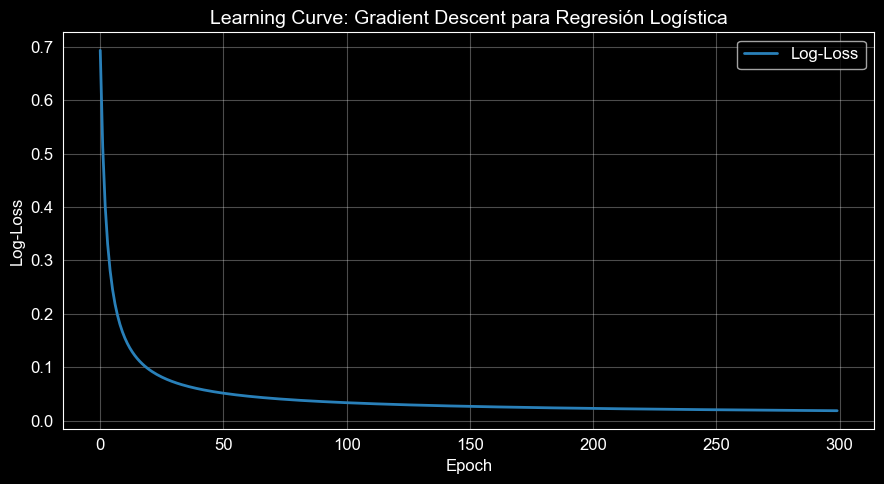

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(loss_history, '-', color='#2980b9', lw=2, label='Log-Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Log-Loss')
ax.set_title('Learning Curve: Gradient Descent para Regresión Logística')
ax.legend(); plt.tight_layout(); plt.show()

---
## Paso 5: Clase `LogisticRegressionGD`

### Tarea 3: Completar la clase con `fit`, `predict_proba` y `predict`

In [10]:
class LogisticRegressionGD:
    def __init__(self, lr=0.1, n_epochs=300, threshold=0.5):
        self.lr = lr
        self.n_epochs = n_epochs
        self.threshold = threshold # Umbral para clasificación binaria, típicamente 0.5
        self.w = None
        self.loss_history = []

    def _augment(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X] # Agregar término de sesgo (bias)

    def fit(self, X, y):
        # TODO: Implementar (augmentar X, inicializar w, bucle GD)
        X_aug = self._augment(X)
        self.w = np.zeros(X_aug.shape[1])
        self.loss_history = []

        for epoch in range(self.n_epochs):
            loss = calcular_log_loss(X_aug, y, self.w)
            grad = calcular_gradiente(X_aug, y, self.w)
            self.w = self.w - self.lr * grad
            self.loss_history.append(loss)
        return self

    def predict_proba(self, X):
        # TODO: Retorna probabilidades de clase 1
        X_aug = self._augment(X)
        return sigmoid(X_aug @ self.w)

    def predict(self, X):
        # TODO: Retorna predicciones binarias (0 o 1)
        return (self.predict_proba(X) >= self.threshold).astype(int)

---
## Paso 6: Entrenar y Evaluar

### Tarea 4: Entrenar el modelo y evaluar con métricas

1. Dividir `X_raw` y `y` en train/test
2. Crear instancia de `LogisticRegressionGD` y entrenar
3. Predecir y calcular: accuracy, precision, recall, F1-score
4. Mostrar confusion matrix y classification report

In [11]:
from sklearn.model_selection import train_test_split

# TODO Dividir datos de entrenamiento y prueba usando train_test_split y entrenar el modelo LogisticRegressionGD
X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

#Entrenamos el modelo
modelo = LogisticRegressionGD(lr=0.1, n_epochs=300, threshold=0.5)
modelo.fit(X_tr, y_tr)

EVALUACIÓN — LogisticRegressionGD
Accuracy        1.0000
Precision       1.0000
Recall          1.0000
F1-Score        1.0000

Classification Report:
              precision    recall  f1-score   support

     Clase 0       1.00      1.00      1.00        40
     Clase 1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



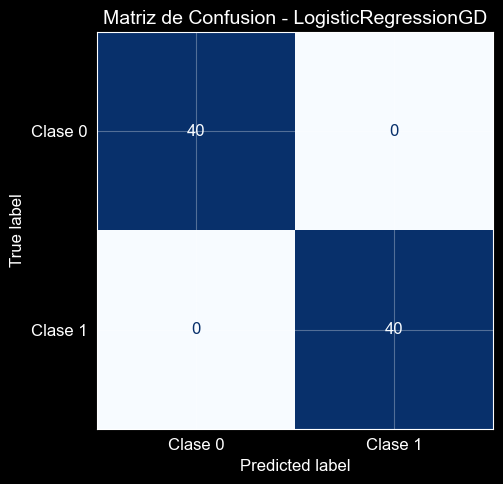

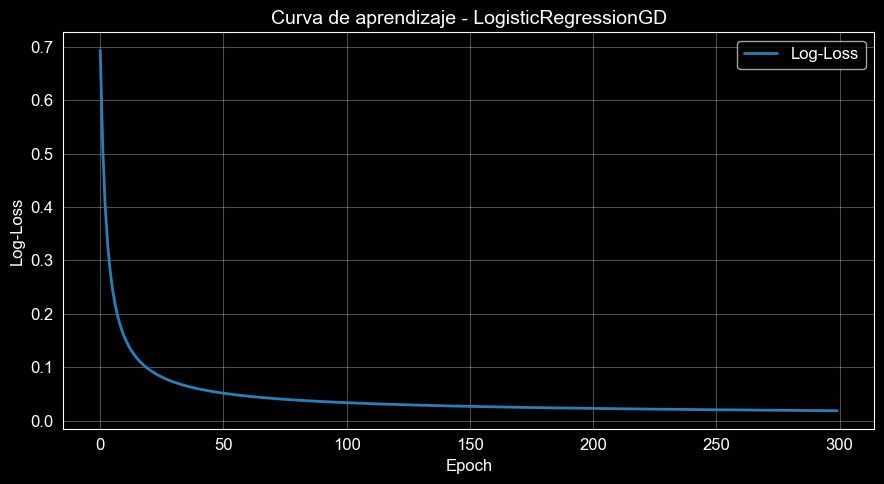

In [12]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)


# TODO: Predecir y evaluar

#Predecimos
y_pred = modelo.predict(X_te)

#Evaluacion
print("=" * 50)
print("EVALUACIÓN — LogisticRegressionGD")
print("=" * 50)
print(f"{'Accuracy':<15} {accuracy_score(y_te, y_pred):.4f}")
print(f"{'Precision':<15} {precision_score(y_te, y_pred):.4f}")
print(f"{'Recall':<15} {recall_score(y_te, y_pred):.4f}")
print(f"{'F1-Score':<15} {f1_score(y_te, y_pred):.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_te, y_pred, target_names=['Clase 0', 'Clase 1']))

#Matriz de confusion
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred),
    display_labels=['Clase 0', 'Clase 1']
).plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title("Matriz de Confusion - LogisticRegressionGD")
plt.tight_layout()
plt.show()

#Curva de aprendizaje del modelo final
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(modelo.loss_history, '-', color='#2980b9' , lw=2 ,label='Log-Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Log-Loss')
ax.set_title('Curva de aprendizaje - LogisticRegressionGD')
ax.legend(); plt.tight_layout(); plt.show()

## Paso 7: Visualización de la Frontera de Decisión

La frontera de decisión es el conjunto de puntos donde el modelo
es igualmente probable para ambas clases, es decir donde
$P(Y=1|\mathbf{x}) = 0.5$, lo que ocurre cuando:

$$w_0 + w_1 x_1 + w_2 x_2 = 0$$

Despejando $x_2$:

$$x_2 = -\frac{w_0 + w_1 x_1}{w_2}$$

Con los pesos obtenidos ($w_0 = 0.063$, $w_1 = -1.378$, $w_2 = -1.593$):

$$x_2 = -\frac{0.063 + (-1.378)\, x_1}{-1.593} = \frac{0.063 - 1.378\, x_1}{1.593}$$

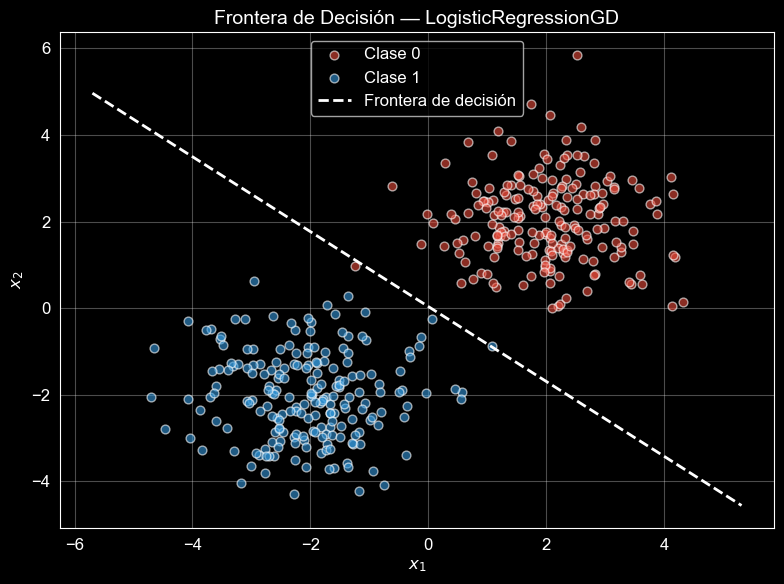

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

# Datos
ax.scatter(X_raw[y==0, 0], X_raw[y==0, 1],
           color='#e74c3c', alpha=0.6, s=40, edgecolors='white', label='Clase 0')
ax.scatter(X_raw[y==1, 0], X_raw[y==1, 1],
           color='#3498db', alpha=0.6, s=40, edgecolors='white', label='Clase 1')

# Frontera de decisión: w0 + w1*x1 + w2*x2 = 0
# Despejando x2: x2 = -(w0 + w1*x1) / w2
x1_range = np.linspace(X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1, 300)
x2_boundary = -(modelo.w[0] + modelo.w[1] * x1_range) / modelo.w[2]

ax.plot(x1_range, x2_boundary, '--', color='white', lw=2, label='Frontera de decisión')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Frontera de Decisión — LogisticRegressionGD')
ax.legend()
plt.tight_layout()
plt.show()

## Resumen del Laboratorio 3

### ¿Qué construimos?

Una implementación completa de Regresión Logística Binaria **desde cero**
usando únicamente NumPy, siguiendo exactamente el mismo flujo matemático
que usa scikit-learn internamente.

---

### Paso 2 Design Matrix aumentada

Para incorporar el bias $\beta_0$ sin tratarlo como parámetro especial,
se agrega una columna de unos al inicio de $\mathbf{X}$:

$$\mathbf{X}_{\text{aug}} = \begin{bmatrix} 1 & x_{11} & x_{12} \\
1 & x_{21} & x_{22} \\ \vdots & \vdots & \vdots \\
1 & x_{n1} & x_{n2} \end{bmatrix} \in \mathbb{R}^{n \times 3}$$

Así el vector de pesos $\mathbf{w} = [w_0, w_1, w_2]^\top$ incluye el
bias como primer elemento, y el producto $\mathbf{X}_{\text{aug}}\mathbf{w}$
computa automáticamente $w_0 + w_1 x_1 + w_2 x_2$ para cada muestra.
```python
X = np.c_[np.ones((n_samples, 1)), X_raw]
# X_raw: (400, 2)  ->  X: (400, 3)
```

---

### Paso 3 Función sigmoide

Mapea cualquier valor real al intervalo $(0, 1)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
```python
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
```

Propiedades clave:
- $\sigma(0) = 0.5$ → punto de frontera de decisión
- $\sigma(z) \to 1$ cuando $z \to +\infty$
- $\sigma(z) \to 0$ cuando $z \to -\infty$

---

### Paso 3 Función de costo: Binary Cross-Entropy

$$J(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n}
\left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

donde $\hat{y}_i = \sigma(\mathbf{x}_i^\top \mathbf{w})$.
```python
def calcular_log_loss(X, y, w):
    epsilon = 1e-7                               # evitar log(0)
    y_hat = sigmoid(X @ w)
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
```

El `np.clip` es una protección numérica: si $\hat{y}_i = 0$ exacto,
$\log(0) = -\infty$ y el cálculo colapsa. El epsilon desplaza las
predicciones al rango $[10^{-7},\, 1 - 10^{-7}]$.

---

### Paso 3 Gradiente vectorizado

La derivada de $J$ respecto a $\mathbf{w}$ tiene la siguiente forma:

$$\nabla_{\mathbf{w}} J = \frac{1}{n} \mathbf{X}^\top
(\hat{\mathbf{y}} - \mathbf{y})$$
```python
def calcular_gradiente(X, y, w):
    y_hat = sigmoid(X @ w)
    return (1 / n) * X.T @ (y_hat - y)
```

El vector $(\hat{\mathbf{y}} - \mathbf{y})$ mide el error por muestra.
Multiplicar por $\mathbf{X}^\top$ proyecta ese error sobre cada feature,
produciendo la dirección de máximo ascenso de $J$.

---

### Paso 4 Gradient Descent

La regla de actualización resta la dirección del gradiente escalada
por la tasa de aprendizaje $\alpha$:

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \alpha\,
\nabla_{\mathbf{w}} J(\mathbf{w}^{(t)})$$
```python
lr, n_epochs = 0.1, 300
w = np.zeros(X_train.shape[1])

for epoch in range(n_epochs):
    loss = calcular_log_loss(X_train, y_train, w)
    grad = calcular_gradiente(X_train, y_train, w)
    w    = w - lr * grad
    loss_history.append(loss)
```
```
Pesos finales: [ 0.06312841 -1.37823833 -1.59339551]
Loss final:    0.018838
```

$w_0 = 0.063$ es el bias. $w_1 = -1.378$ y $w_2 = -1.593$ son los
pesos de $x_1$ y $x_2$ ambos son negativos, porque la Clase 1 se ubica
en la región $x_1 < 0,\, x_2 < 0$ del espacio de features.

La **learning curve** confirma una buena convergencia: caída rápida
en las primeras 50 épocas y estabilización asintótica sin
oscilaciones (lr no es demasiado grande), ni estancamiento (lr no
es demasiado pequeño).

---

### Paso 5 Clase `LogisticRegressionGD`

Encapsula todo el flujo con una API compatible con scikit-learn:
```python
class LogisticRegressionGD:
    def fit(self, X, y):
        X_aug  = self._augment(X)   # agrega columna de 1s internamente
        self.w = np.zeros(X_aug.shape[1])
        for _ in range(self.n_epochs):
            loss      = calcular_log_loss(X_aug, y, self.w)
            grad      = calcular_gradiente(X_aug, y, self.w)
            self.w    = self.w - self.lr * grad
            self.loss_history.append(loss)

    def predict_proba(self, X):
        return sigmoid(self._augment(X) @ self.w)  # probabilidades ∈ (0,1)

    def predict(self, X):
        return (self.predict_proba(X) >= self.threshold).astype(int)
```

**Nota importante sobre `X_raw` vs `X`:**
```
X_raw -> (400, 2)  <- entrada de la clase (sin columna de 1s)
X     -> (400, 3)  <- augmentada en Paso 2, No la uso en la clase
```

La clase llama `_augment` internamente, por eso siempre se le pasa
`X_raw`. Si usará `X` (ya augmentada) generaría una columna de 1s doble
y pesos incorrectos sin ningún error explícito.

---

### Paso 6 Evaluación
```
Accuracy   1.0000
Precision  1.0000
Recall     1.0000
F1-Score   1.0000
```
```
              Pred 0   Pred 1
Real Clase 0    40        0
Real Clase 1     0       40
```

Accuracy perfecta esperada: los datos son **linealmente separables**
por construcción (dos nubes gaussianas separadas por $\Delta\mu = 4$
unidades en ambas dimensiones). La regresión logística con GD
encontró la frontera de decisión óptima:

$$w_0 + w_1 x_1 + w_2 x_2 = 0$$

$$0.063 - 1.378\, x_1 - 1.593\, x_2 = 0$$

que separa perfectamente ambas clases en el espacio 2D.

---

**Referencias**

> Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*. Springer.
>
> Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of
> Statistical Learning* (2nd ed.). Springer.
>
> Murphy, K.P. (2022). *Probabilistic Machine Learning: An Introduction*.
> MIT Press.